In [1]:
import requests
from xml.etree import ElementTree as ET

wfs_2011 = "https://gdi.berlin.de/services/wfs/ua_einwohnerdichte_2011"
wfs_2022 = "https://gdi.berlin.de/services/wfs/ua_einwohnerdichte_2022"

In [2]:
params = {
    "service": "WFS",
    "request": "GetCapabilities"
}

r2011 = requests.get(wfs_2011, params=params)
r2022 = requests.get(wfs_2022, params=params)

print("2011:", r2011.status_code, r2011.headers.get("content-type"))
print("2022:", r2022.status_code, r2022.headers.get("content-type"))

print(r2011.text[:500])
print(r2022.text[:500])

2011: 200 application/xml
2022: 200 application/xml
<?xml version="1.0" encoding="UTF-8"?><wfs:WFS_Capabilities version="2.0.0" xmlns:xsi="http://www.w3.org/2001/XMLSchema-instance" xmlns="http://www.opengis.net/wfs/2.0" xmlns:wfs="http://www.opengis.net/wfs/2.0" xmlns:ows="http://www.opengis.net/ows/1.1" xmlns:gml="http://www.opengis.net/gml/3.2" xmlns:fes="http://www.opengis.net/fes/2.0" xmlns:xlink="http://www.w3.org/1999/xlink" xmlns:xs="http://www.w3.org/2001/XMLSchema" xsi:schemaLocation="http://www.opengis.net/wfs/2.0 http://schemas.opengi
<?xml version="1.0" encoding="UTF-8"?><wfs:WFS_Capabilities version="2.0.0" xmlns:xsi="http://www.w3.org/2001/XMLSchema-instance" xmlns="http://www.opengis.net/wfs/2.0" xmlns:wfs="http://www.opengis.net/wfs/2.0" xmlns:ows="http://www.opengis.net/ows/1.1" xmlns:gml="http://www.opengis.net/gml/3.2" xmlns:fes="http://www.opengis.net/fes/2.0" xmlns:xlink="http://www.w3.org/1999/xlink" xmlns:xs="http://www.w3.org/2001/XMLSchema" xsi:schemaLocation=

In [3]:
import re

print("2011 feature types:")
print(re.findall(r"<(?:\w+:)?Name>(.*?)</(?:\w+:)?Name>", r2011.text)[:30])

print("\n2022 feature types:")
print(re.findall(r"<(?:\w+:)?Name>(.*?)</(?:\w+:)?Name>", r2022.text)[:30])

2011 feature types:
['ua_einwohnerdichte_2011:ua_einwohnerdichte_2011']

2022 feature types:
['ua_einwohnerdichte_2022:einwohnerdichte2022', 'ua_einwohnerdichte_2022:einwohnerdichte2022_entw']


In [4]:
import geopandas as gpd
import requests
from io import BytesIO

url_2011 = "https://gdi.berlin.de/services/wfs/ua_einwohnerdichte_2011"
url_2022 = "https://gdi.berlin.de/services/wfs/ua_einwohnerdichte_2022"

def get_wfs_sample(url, typename, count=5):
    params = {
        "service": "WFS",
        "version": "2.0.0",
        "request": "GetFeature",
        "typeNames": typename,
        "outputFormat": "application/json",
        "count": count
    }
    
    r = requests.get(url, params=params)
    print("Status:", r.status_code)
    print("Content-Type:", r.headers.get("content-type"))
    print("URL:", r.url)
    
    r.raise_for_status()
    return gpd.read_file(BytesIO(r.content))

gdf_2011_sample = get_wfs_sample(
    url_2011,
    "ua_einwohnerdichte_2011:ua_einwohnerdichte_2011"
)

gdf_2022_sample = get_wfs_sample(
    url_2022,
    "ua_einwohnerdichte_2022:einwohnerdichte2022"
)

gdf_2022_entw_sample = get_wfs_sample(
    url_2022,
    "ua_einwohnerdichte_2022:einwohnerdichte2022_entw"
)

Status: 200
Content-Type: application/json;charset=UTF-8
URL: https://gdi.berlin.de/services/wfs/ua_einwohnerdichte_2011?service=WFS&version=2.0.0&request=GetFeature&typeNames=ua_einwohnerdichte_2011%3Aua_einwohnerdichte_2011&outputFormat=application%2Fjson&count=5
Status: 200
Content-Type: application/json;charset=UTF-8
URL: https://gdi.berlin.de/services/wfs/ua_einwohnerdichte_2022?service=WFS&version=2.0.0&request=GetFeature&typeNames=ua_einwohnerdichte_2022%3Aeinwohnerdichte2022&outputFormat=application%2Fjson&count=5
Status: 200
Content-Type: application/json;charset=UTF-8
URL: https://gdi.berlin.de/services/wfs/ua_einwohnerdichte_2022?service=WFS&version=2.0.0&request=GetFeature&typeNames=ua_einwohnerdichte_2022%3Aeinwohnerdichte2022_entw&outputFormat=application%2Fjson&count=5


In [5]:
print("========== 2011 ==========")
display(gdf_2011_sample.head())
print("Columns:", list(gdf_2011_sample.columns))
print("CRS:", gdf_2011_sample.crs)
print("Geometry:", gdf_2011_sample.geom_type.value_counts())

print("\n========== 2022 PRIMARY ==========")
display(gdf_2022_sample.head())
print("Columns:", list(gdf_2022_sample.columns))
print("CRS:", gdf_2022_sample.crs)
print("Geometry:", gdf_2022_sample.geom_type.value_counts())

print("\n========== 2022 ENTW ==========")
display(gdf_2022_entw_sample.head())
print("Columns:", list(gdf_2022_entw_sample.columns))
print("CRS:", gdf_2022_entw_sample.crs)
print("Geometry:", gdf_2022_entw_sample.geom_type.value_counts())

========== 2011 ==========


,id,schluessel,summe,fl_ha,ew_pro_ha,geometry
0,ua_einwohnerdichte_2011.0100980011000100,0100980011000100,3,0.42,7,"MULTIPOLYGON (((389335.221 5821739.127, 389356..."
1,ua_einwohnerdichte_2011.0100980071000100,0100980071000100,270,1.03,261,"MULTIPOLYGON (((389747.76 5821227.617, 389714...."
2,ua_einwohnerdichte_2011.0100980081000100,0100980081000100,340,2.34,145,"MULTIPOLYGON (((390067.012 5821486.085, 390125..."
3,ua_einwohnerdichte_2011.0100980081000200,0100980081000200,419,1.42,294,"MULTIPOLYGON (((389945.314 5821313.499, 389942..."
4,ua_einwohnerdichte_2011.0100980211000000,0100980211000000,132,0.77,170,"MULTIPOLYGON (((389898.887 5820411.531, 389935..."


Columns: ['id', 'schluessel', 'summe', 'fl_ha', 'ew_pro_ha', 'geometry']
CRS: EPSG:25833
Geometry: MultiPolygon    5
Name: count, dtype: int64

========== 2022 PRIMARY ==========


,id,schluessel,ew2022,flalle,ew_ha_2022,alter_u6,alter_6_u10,alter_10_u18,alter_18_u65,alter_65_u70,alter_70_u75,alter75_u80,alter_80plus,typklar,geometry
0,einwohnerdichte2022.0100980011000100,0100980011000100,0,4623.97,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Freie Zeilenbebauung mit landschaftlichem Sied...,"MULTIPOLYGON (((389424.849 5821759.519, 389373..."
1,einwohnerdichte2022.0100980011000200,0100980011000200,0,13430.94,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Parkplatz,"MULTIPOLYGON (((389424.849 5821759.519, 389336..."
2,einwohnerdichte2022.0100980011000300,0100980011000300,18,5603.76,32.12,0.0,0.0,3.0,12.0,3.0,0.0,0.0,0.0,Geschosswohnungsbau der 1990er Jahre und jünger,"MULTIPOLYGON (((389326.319 5821907.843, 389287..."
3,einwohnerdichte2022.0100980021000200,0100980021000200,850,34344.73,247.49,56.0,34.0,48.0,629.0,24.0,22.0,16.0,21.0,"Heterogene, innerstädtische Mischbebauung, Lüc...","MULTIPOLYGON (((389743.255 5822026.125, 389703..."
4,einwohnerdichte2022.0100980021000300,0100980021000300,3,48930.21,0.61,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,Krankenhaus,"MULTIPOLYGON (((389693.578 5821875.268, 389605..."


Columns: ['id', 'schluessel', 'ew2022', 'flalle', 'ew_ha_2022', 'alter_u6', 'alter_6_u10', 'alter_10_u18', 'alter_18_u65', 'alter_65_u70', 'alter_70_u75', 'alter75_u80', 'alter_80plus', 'typklar', 'geometry']
CRS: EPSG:25833
Geometry: MultiPolygon    5
Name: count, dtype: int64

========== 2022 ENTW ==========


,id,schluessel,ew2021,ew2022,flalle,ha,ew_ha_2021,ew_ha_2022,diff_2022_2021,typklar,etypklar,geometry
0,einwohnerdichte2022_entw.0100980011000100,0100980011000100,0,0,4623.97,0.46,0.00,0.00,0.00,Freie Zeilenbebauung mit landschaftlichem Sied...,"Free row development, landscaped residential g...","MULTIPOLYGON (((389424.849 5821759.519, 389373..."
1,einwohnerdichte2022_entw.0100980011000200,0100980011000200,0,0,13430.94,1.34,0.00,0.00,0.00,Parkplatz,Parking area,"MULTIPOLYGON (((389424.849 5821759.519, 389336..."
2,einwohnerdichte2022_entw.0100980011000300,0100980011000300,18,18,5603.76,0.56,32.12,32.12,0.00,Geschosswohnungsbau der 1990er Jahre und jünger,Rental-flat buildings of the 1990s and later,"MULTIPOLYGON (((389326.319 5821907.843, 389287..."
3,einwohnerdichte2022_entw.0100980021000200,0100980021000200,842,850,34344.73,3.43,245.16,247.49,2.33,"Heterogene, innerstädtische Mischbebauung, Lüc...","Heterogeneous inner-city mixed development, po...","MULTIPOLYGON (((389743.255 5822026.125, 389703..."
4,einwohnerdichte2022_entw.0100980021000300,0100980021000300,0,3,48930.21,4.89,0.00,0.61,0.61,Krankenhaus,Hospital,"MULTIPOLYGON (((389693.578 5821875.268, 389605..."


Columns: ['id', 'schluessel', 'ew2021', 'ew2022', 'flalle', 'ha', 'ew_ha_2021', 'ew_ha_2022', 'diff_2022_2021', 'typklar', 'etypklar', 'geometry']
CRS: EPSG:25833
Geometry: MultiPolygon    5
Name: count, dtype: int64


In [6]:
print("========== 2011 ==========")
print(list(gdf_2011_sample.columns))
display(gdf_2011_sample.head(2))

print("\n========== 2022 PRIMARY ==========")
print(list(gdf_2022_sample.columns))
display(gdf_2022_sample.head(2))

print("\n========== 2022 ENTW ==========")
print(list(gdf_2022_entw_sample.columns))
display(gdf_2022_entw_sample.head(2))

========== 2011 ==========
['id', 'schluessel', 'summe', 'fl_ha', 'ew_pro_ha', 'geometry']


,id,schluessel,summe,fl_ha,ew_pro_ha,geometry
0,ua_einwohnerdichte_2011.0100980011000100,0100980011000100,3,0.42,7,"MULTIPOLYGON (((389335.221 5821739.127, 389356..."
1,ua_einwohnerdichte_2011.0100980071000100,0100980071000100,270,1.03,261,"MULTIPOLYGON (((389747.76 5821227.617, 389714...."



========== 2022 PRIMARY ==========
['id', 'schluessel', 'ew2022', 'flalle', 'ew_ha_2022', 'alter_u6', 'alter_6_u10', 'alter_10_u18', 'alter_18_u65', 'alter_65_u70', 'alter_70_u75', 'alter75_u80', 'alter_80plus', 'typklar', 'geometry']


,id,schluessel,ew2022,flalle,ew_ha_2022,alter_u6,alter_6_u10,alter_10_u18,alter_18_u65,alter_65_u70,alter_70_u75,alter75_u80,alter_80plus,typklar,geometry
0,einwohnerdichte2022.0100980011000100,0100980011000100,0,4623.97,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Freie Zeilenbebauung mit landschaftlichem Sied...,"MULTIPOLYGON (((389424.849 5821759.519, 389373..."
1,einwohnerdichte2022.0100980011000200,0100980011000200,0,13430.94,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Parkplatz,"MULTIPOLYGON (((389424.849 5821759.519, 389336..."



========== 2022 ENTW ==========
['id', 'schluessel', 'ew2021', 'ew2022', 'flalle', 'ha', 'ew_ha_2021', 'ew_ha_2022', 'diff_2022_2021', 'typklar', 'etypklar', 'geometry']


,id,schluessel,ew2021,ew2022,flalle,ha,ew_ha_2021,ew_ha_2022,diff_2022_2021,typklar,etypklar,geometry
0,einwohnerdichte2022_entw.0100980011000100,0100980011000100,0,0,4623.97,0.46,0.0,0.0,0.0,Freie Zeilenbebauung mit landschaftlichem Sied...,"Free row development, landscaped residential g...","MULTIPOLYGON (((389424.849 5821759.519, 389373..."
1,einwohnerdichte2022_entw.0100980011000200,0100980011000200,0,0,13430.94,1.34,0.0,0.0,0.0,Parkplatz,Parking area,"MULTIPOLYGON (((389424.849 5821759.519, 389336..."


In [7]:
keys_2011 = set(gdf_2011_sample["schluessel"].astype(str))
keys_2022 = set(gdf_2022_sample["schluessel"].astype(str))

print("2011 sample keys:", keys_2011)
print("2022 sample keys:", keys_2022)

2011 sample keys: {'0100980081000100', '0100980211000000', '0100980011000100', '0100980081000200', '0100980071000100'}
2022 sample keys: {'0100980021000200', '0100980011000200', '0100980021000300', '0100980011000100', '0100980011000300'}


In [8]:
import requests
import geopandas as gpd
from io import BytesIO

def get_wfs_all(url, typename, page_size=10000):
    all_gdfs = []
    start_index = 0

    while True:
        params = {
            "service": "WFS",
            "version": "2.0.0",
            "request": "GetFeature",
            "typeNames": typename,
            "outputFormat": "application/json",
            "count": page_size,
            "startIndex": start_index
        }

        r = requests.get(url, params=params)
        r.raise_for_status()

        gdf = gpd.read_file(BytesIO(r.content))

        if len(gdf) == 0:
            break

        all_gdfs.append(gdf)

        print(f"Retrieved {start_index} → {start_index + len(gdf)}")

        if len(gdf) < page_size:
            break

        start_index += page_size

    return gpd.GeoDataFrame(
        pd.concat(all_gdfs, ignore_index=True),
        crs=all_gdfs[0].crs
    )

In [11]:
import pandas as pd
density_2011 = get_wfs_all(
    url_2011,
    "ua_einwohnerdichte_2011:ua_einwohnerdichte_2011"
)

density_2022 = get_wfs_all(
    url_2022,
    "ua_einwohnerdichte_2022:einwohnerdichte2022"
)

Retrieved 0 → 10000
Retrieved 10000 → 14459
Retrieved 0 → 10000
Retrieved 10000 → 20000
Retrieved 20000 → 26397


In [12]:
print("========== DATASET SIZES ==========")
print("2011:", density_2011.shape)
print("2022:", density_2022.shape)

print("\n========== UNIQUE KEYS ==========")
print("2011:", density_2011["schluessel"].nunique())
print("2022:", density_2022["schluessel"].nunique())

print("\n========== DUPLICATE KEYS ==========")
print("2011 duplicate keys:",
      density_2011["schluessel"].duplicated().sum())

print("2022 duplicate keys:",
      density_2022["schluessel"].duplicated().sum())

print("\n========== KEY OVERLAP ==========")
keys_2011 = set(density_2011["schluessel"].astype(str))
keys_2022 = set(density_2022["schluessel"].astype(str))

print("Common keys:", len(keys_2011 & keys_2022))
print("Only 2011:", len(keys_2011 - keys_2022))
print("Only 2022:", len(keys_2022 - keys_2011))

========== DATASET SIZES ==========
2011: (14459, 6)
2022: (26397, 15)

========== UNIQUE KEYS ==========
2011: 14459
2022: 26397

========== DUPLICATE KEYS ==========
2011 duplicate keys: 0
2022 duplicate keys: 0

========== KEY OVERLAP ==========
Common keys: 13913
Only 2011: 546
Only 2022: 12484


In [13]:
print("\n========== AREA STATISTICS ==========")

print("2011 area ha:")
print(density_2011["fl_ha"].describe())

print("\n2022 area:")
print(density_2022["flalle"].describe())


========== AREA STATISTICS ==========
2011 area ha:
count    14459.000000
mean         2.587593
std          3.788511
min          0.040000
25%          1.150000
50%          1.820000
75%          2.850000
max        141.820000
Name: fl_ha, dtype: float64

2022 area:
count    2.639700e+04
mean     3.007410e+04
std      6.382849e+04
min      3.533000e+01
25%      9.775720e+03
50%      1.738056e+04
75%      3.013134e+04
max      4.233009e+06
Name: flalle, dtype: float64


In [14]:
print("\n========== DENSITY STATISTICS ==========")

print("2011:")
print(density_2011["ew_pro_ha"].describe())

print("\n2022:")
print(density_2022["ew_ha_2022"].describe())


========== DENSITY STATISTICS ==========
2011:
count    14459.000000
mean       122.976347
std        141.080864
min          0.000000
25%         30.000000
50%         54.000000
75%        184.000000
max       1141.000000
Name: ew_pro_ha, dtype: float64

2022:
count    26397.000000
mean        78.185436
std        133.561728
min          0.000000
25%          0.000000
50%         19.390000
75%         79.890000
max       1105.680000
Name: ew_ha_2022, dtype: float64


In [15]:
import matplotlib.pyplot as plt

print("2011 total bounds:")
print(density_2011.total_bounds)

print("\n2022 total bounds:")
print(density_2022.total_bounds)

2011 total bounds:
[ 370300.1516 5799674.6327  414010.7268 5835914.9749]

2022 total bounds:
[ 370000.825 5799520.66   415786.553 5837259.27 ]


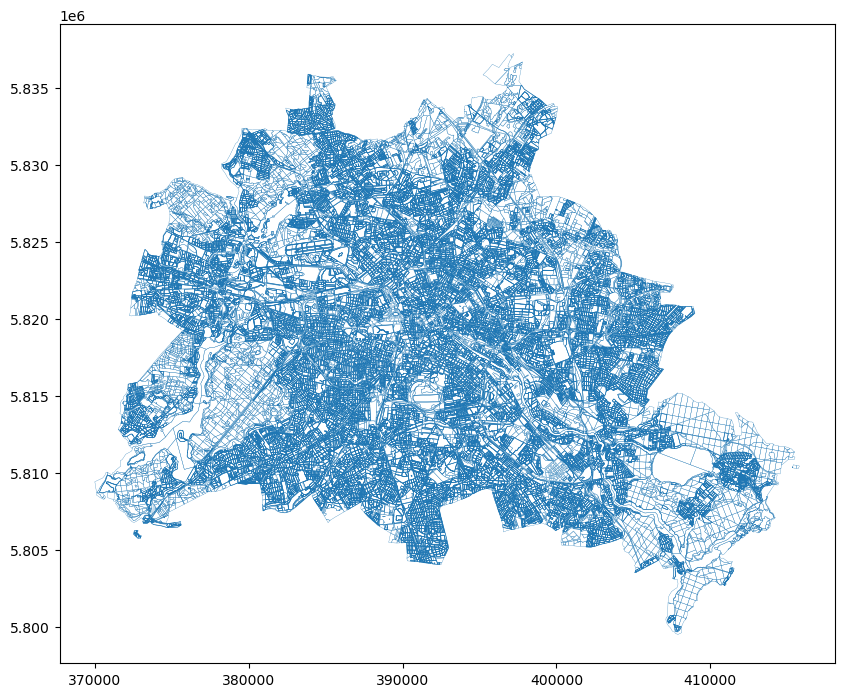

In [16]:
fig, ax = plt.subplots(figsize=(10, 10))

density_2011.boundary.plot(ax=ax, linewidth=0.5)
density_2022.boundary.plot(ax=ax, linewidth=0.2)

plt.show()

In [17]:
import geopandas as gpd
import fiona

gpkg_path = r"C:\Users\deqin\Downloads\MATCAD_Energy_Age_Denkmal_FINAL.gpkg"

print(fiona.listlayers(gpkg_path))

['matcad_energy_age_denkmal']


In [18]:
master = gpd.read_file(gpkg_path)

In [19]:
print(master.shape)
print(master.crs)
print(master.columns.tolist())

(327295, 90)
EPSG:25833
['bldg_gmlid', 'AGS', 'bldg_area', 'bldg_volume', 'bldg_function', 'BtySetID', 'BtyID', 'BtySig', 'Mat_Sum', 'Mat_ConNrm', 'Mat_ConLgt', 'Mat_BriBrt', 'Mat_BriIns', 'Mat_ClyRcv', 'Mat_CalMrt', 'Mat_AnhMrt', 'Mat_LoaMrt', 'Mat_SynMrt', 'Mat_CalScr', 'Mat_AnhScr', 'Mat_AnhDsc', 'Mat_SynScr', 'Mat_SlmBri', 'Mat_AcnBlc', 'Mat_ConBlc', 'Mat_MudBri', 'Mat_GpsPlb', 'Mat_MinCnb', 'Mat_MinIns', 'Mat_ConRcv', 'Mat_FcmRcv', 'Mat_SltRcv', 'Mat_OrgSbs', 'Mat_MinFil', 'Mat_MinGls', 'Mat_NatStn', 'Mat_MinOth', 'Mat_TmbSwn', 'Mat_WodPrc', 'Mat_RnwIns', 'Mat_StrRcv', 'Mat_RnwOth', 'Mat_HcbIns', 'Mat_PlaRcv', 'Mat_HcbRcv', 'Mat_BtmRcv', 'Mat_BtmMem', 'Mat_FemRcv', 'Mat_FemOth', 'Mat_NfeAlm', 'Mat_NfeAlu', 'Mat_NfeCpr', 'Mat_NfeOth', 'id', 'gisid', 'typ_ist', 'typ_mod1', 'k2_w_l', 'nwbz', 'overlap_ratio_matcad', 'bbox_length_m', 'bbox_width_m', 'footprint_area_m2', 'height_proxy_m', 'energy_intensity_kwh_m3a', 'denkmal_status', 'index_age', 'age_schluessel', 'freistehen', 'anderer

In [20]:
for col in ["id", "gisid", "AGS", "typ", "typklar"]:
    print(f"\n--- {col} ---")
    print("dtype:", master[col].dtype)
    print("unique:", master[col].nunique())
    print(master[col].head(10).tolist())


--- id ---
dtype: object
unique: 327215
['a_waermeversorg_gebaeudedaten_2022.G427469', 'a_waermeversorg_gebaeudedaten_2022.G406691', 'a_waermeversorg_gebaeudedaten_2022.G172069', 'a_waermeversorg_gebaeudedaten_2022.G409705', 'a_waermeversorg_gebaeudedaten_2022.G361278', 'a_waermeversorg_gebaeudedaten_2022.G172645', 'a_waermeversorg_gebaeudedaten_2022.G177898', 'a_waermeversorg_gebaeudedaten_2022.G202339', 'a_waermeversorg_gebaeudedaten_2022.G152015', 'a_waermeversorg_gebaeudedaten_2022.G175914']

--- gisid ---
dtype: object
unique: 327215
['G427469', 'G406691', 'G172069', 'G409705', 'G361278', 'G172645', 'G177898', 'G202339', 'G152015', 'G175914']

--- AGS ---
dtype: int64
unique: 1
[11000000, 11000000, 11000000, 11000000, 11000000, 11000000, 11000000, 11000000, 11000000, 11000000]

--- typ ---
dtype: float64
unique: 46
[nan, 11.0, 22.0, 23.0, 23.0, nan, 22.0, 23.0, 23.0, nan]

--- typklar ---
dtype: object
unique: 46
[None, 'Freie Zeilenbebauung (1950er-1970er), mit landschaftlichem 

In [21]:
print(master[["id", "gisid", "AGS"]].head(20))

                                            id    gisid       AGS
0   a_waermeversorg_gebaeudedaten_2022.G427469  G427469  11000000
1   a_waermeversorg_gebaeudedaten_2022.G406691  G406691  11000000
2   a_waermeversorg_gebaeudedaten_2022.G172069  G172069  11000000
3   a_waermeversorg_gebaeudedaten_2022.G409705  G409705  11000000
4   a_waermeversorg_gebaeudedaten_2022.G361278  G361278  11000000
5   a_waermeversorg_gebaeudedaten_2022.G172645  G172645  11000000
6   a_waermeversorg_gebaeudedaten_2022.G177898  G177898  11000000
7   a_waermeversorg_gebaeudedaten_2022.G202339  G202339  11000000
8   a_waermeversorg_gebaeudedaten_2022.G152015  G152015  11000000
9   a_waermeversorg_gebaeudedaten_2022.G175914  G175914  11000000
10  a_waermeversorg_gebaeudedaten_2022.G229753  G229753  11000000
11  a_waermeversorg_gebaeudedaten_2022.G165809  G165809  11000000
12  a_waermeversorg_gebaeudedaten_2022.G254444  G254444  11000000
13  a_waermeversorg_gebaeudedaten_2022.G188936  G188936  11000000
14  a_waer

In [22]:
import re

for col in master.columns:
    if master[col].dtype == "object":
        sample_values = master[col].dropna().astype(str).head(1000)

        matches = sample_values[
            sample_values.str.match(r"^\d{16}$")
        ]

        if len(matches) > 0:
            print(col, matches.head().tolist())

age_schluessel ['1601436081000300', '0800390201000000', '2301901371000000', '1501240971000000', '0800372111000000']


In [23]:
# Compare the spatial-key fields from MATCAD and population layers

print("MATCAD age_schluessel examples:")
print(master["age_schluessel"].dropna().astype(str).head(20).tolist())

print("\n2011 population schluessel examples:")
print(pop_2011["schluessel"].astype(str).head(20).tolist())

print("\n2022 population schluessel examples:")
print(pop_2022["schluessel"].astype(str).head(20).tolist())

MATCAD age_schluessel examples:
['1601436081000300', '0800390201000000', '2301901371000000', '1501240971000000', '0800372111000000', '1000520591000300', '0800277621000500', '1200676271000000', '0800396441000300', '1000530361000000', '0800391051000000', '0800327491000300', '0800396371000700', '0800380441000500', '0800371011000000', '0800371581000000', '2301902101000000', '0800376461000000', '1901650391000100', '0800272691000000']

2011 population schluessel examples:


NameError: name 'pop_2011' is not defined

In [24]:
for name, series in {
    "MATCAD age_schluessel": master["age_schluessel"].dropna().astype(str),
    "2011 schluessel": pop_2011["schluessel"].dropna().astype(str),
    "2022 schluessel": pop_2022["schluessel"].dropna().astype(str),
}.items():

    print(f"\n--- {name} ---")
    print("Number of values:", len(series))
    print("Unique:", series.nunique())
    print("Length distribution:")
    print(series.str.len().value_counts().sort_index())
    print("First 10:")
    print(series.head(10).tolist())

NameError: name 'pop_2011' is not defined

In [25]:
id="z1"
# Show variables currently available in the notebook
for name, value in list(globals().items()):
    if isinstance(value, gpd.GeoDataFrame):
        print(
            name,
            "| rows:", len(value),
            "| CRS:", value.crs,
            "| columns:", list(value.columns)
        )

gdf_2011_sample | rows: 5 | CRS: EPSG:25833 | columns: ['id', 'schluessel', 'summe', 'fl_ha', 'ew_pro_ha', 'geometry']
gdf_2022_sample | rows: 5 | CRS: EPSG:25833 | columns: ['id', 'schluessel', 'ew2022', 'flalle', 'ew_ha_2022', 'alter_u6', 'alter_6_u10', 'alter_10_u18', 'alter_18_u65', 'alter_65_u70', 'alter_70_u75', 'alter75_u80', 'alter_80plus', 'typklar', 'geometry']
gdf_2022_entw_sample | rows: 5 | CRS: EPSG:25833 | columns: ['id', 'schluessel', 'ew2021', 'ew2022', 'flalle', 'ha', 'ew_ha_2021', 'ew_ha_2022', 'diff_2022_2021', 'typklar', 'etypklar', 'geometry']
density_2011 | rows: 14459 | CRS: EPSG:25833 | columns: ['id', 'schluessel', 'summe', 'fl_ha', 'ew_pro_ha', 'geometry']
density_2022 | rows: 26397 | CRS: EPSG:25833 | columns: ['id', 'schluessel', 'ew2022', 'flalle', 'ew_ha_2022', 'alter_u6', 'alter_6_u10', 'alter_10_u18', 'alter_18_u65', 'alter_65_u70', 'alter_70_u75', 'alter75_u80', 'alter_80plus', 'typklar', 'geometry']
master | rows: 327295 | CRS: EPSG:25833 | columns: [

In [26]:
import pandas as pd
import numpy as np

matcad_keys_series = (
    master["age_schluessel"]
    .dropna()
    .astype(str)
    .str.strip()
)

keys_2011_series = (
    density_2011["schluessel"]
    .dropna()
    .astype(str)
    .str.strip()
)

keys_2022_series = (
    density_2022["schluessel"]
    .dropna()
    .astype(str)
    .str.strip()
)

for name, series in {
    "MATCAD age_schluessel": matcad_keys_series,
    "2011 WFS schluessel": keys_2011_series,
    "2022 WFS schluessel": keys_2022_series,
}.items():

    print(f"\n--- {name} ---")
    print("Total values:", len(series))
    print("Unique values:", series.nunique())
    print("Length distribution:")
    print(series.str.len().value_counts().sort_index())
    print("Examples:")
    print(series.head(10).tolist())


--- MATCAD age_schluessel ---
Total values: 277131
Unique values: 12610
Length distribution:
age_schluessel
16    277131
Name: count, dtype: int64
Examples:
['1601436081000300', '0800390201000000', '2301901371000000', '1501240971000000', '0800372111000000', '1000520591000300', '0800277621000500', '1200676271000000', '0800396441000300', '1000530361000000']

--- 2011 WFS schluessel ---
Total values: 14459
Unique values: 14459
Length distribution:
schluessel
16    14459
Name: count, dtype: int64
Examples:
['0100980011000100', '0100980071000100', '0100980081000100', '0100980081000200', '0100980211000000', '0100980221000000', '0100980241000100', '0100980261000000', '0100980281000000', '0100980291000000']

--- 2022 WFS schluessel ---
Total values: 26397
Unique values: 26397
Length distribution:
schluessel
16    26397
Name: count, dtype: int64
Examples:
['0100980011000100', '0100980011000200', '0100980011000300', '0100980021000200', '0100980021000300', '0100980021000400', '0100980031000100',

In [27]:
matcad_keys = set(matcad_keys_series)
keys_2011 = set(keys_2011_series)
keys_2022 = set(keys_2022_series)

print("MATCAD unique keys:", len(matcad_keys))
print("2011 unique keys:", len(keys_2011))
print("2022 unique keys:", len(keys_2022))

print("\nExact overlap MATCAD ↔ 2011:",
      len(matcad_keys.intersection(keys_2011)))

print("Exact overlap MATCAD ↔ 2022:",
      len(matcad_keys.intersection(keys_2022)))

print("Exact overlap 2011 ↔ 2022:",
      len(keys_2011.intersection(keys_2022)))

MATCAD unique keys: 12610
2011 unique keys: 14459
2022 unique keys: 26397

Exact overlap MATCAD ↔ 2011: 12527
Exact overlap MATCAD ↔ 2022: 12181
Exact overlap 2011 ↔ 2022: 13913


In [28]:
overlap_2011 = sorted(matcad_keys.intersection(keys_2011))
overlap_2022 = sorted(matcad_keys.intersection(keys_2022))

print("MATCAD ↔ 2011 matching examples:")
print(overlap_2011[:30])

print("\nMATCAD ↔ 2022 matching examples:")
print(overlap_2022[:30])

MATCAD ↔ 2011 matching examples:
['0100980081000100', '0100980081000200', '0100980211000000', '0100980221000000', '0100980261000000', '0100980281000000', '0100980291000000', '0100980301000000', '0100980321000000', '0100986051000100', '0100986051000400', '0100986061000100', '0100986061000600', '0100986091000000', '0100986101000300', '0100986101000400', '0100986101000600', '0100986171000100', '0100986171000200', '0100986171000700', '0100986171000800', '0100986171000900', '0100990031000000', '0100990051000000', '0100990061000000', '0100990071000000', '0100990081000000', '0100990091000200', '0100990101000000', '0100990111000000']

MATCAD ↔ 2022 matching examples:
['0100980081000100', '0100980081000200', '0100980211000000', '0100980221000000', '0100980261000000', '0100980281000000', '0100980291000000', '0100980301000000', '0100980321000000', '0100986051000100', '0100986051000400', '0100986061000100', '0100986061000600', '0100986101000300', '0100986101000400', '0100986101000600', '0100990031

In [29]:
def prefix_overlap(series_a, series_b, n):
    a = set(series_a.astype(str).str[:n])
    b = set(series_b.astype(str).str[:n])
    return len(a & b), len(a), len(b)

for n in [2, 4, 6, 8, 10, 12, 14, 16]:

    overlap, na, nb = prefix_overlap(
        matcad_keys_series,
        keys_2011_series,
        n
    )

    print(
        f"Prefix {n}: overlap={overlap}, "
        f"MATCAD prefixes={na}, WFS prefixes={nb}"
    )

Prefix 2: overlap=23, MATCAD prefixes=23, WFS prefixes=23
Prefix 4: overlap=24, MATCAD prefixes=24, WFS prefixes=24
Prefix 6: overlap=192, MATCAD prefixes=192, WFS prefixes=195
Prefix 8: overlap=2033, MATCAD prefixes=2036, WFS prefixes=2137
Prefix 10: overlap=11264, MATCAD prefixes=11306, WFS prefixes=12388
Prefix 12: overlap=11264, MATCAD prefixes=11306, WFS prefixes=12388
Prefix 14: overlap=12527, MATCAD prefixes=12610, WFS prefixes=14459
Prefix 16: overlap=12527, MATCAD prefixes=12610, WFS prefixes=14459


In [30]:
print("\nMATCAD vs 2022 prefix comparison")

for n in [2, 4, 6, 8, 10, 12, 14, 16]:

    overlap, na, nb = prefix_overlap(
        matcad_keys_series,
        keys_2022_series,
        n
    )

    print(
        f"Prefix {n}: overlap={overlap}, "
        f"MATCAD prefixes={na}, WFS prefixes={nb}"
    )


MATCAD vs 2022 prefix comparison
Prefix 2: overlap=23, MATCAD prefixes=23, WFS prefixes=23
Prefix 4: overlap=24, MATCAD prefixes=24, WFS prefixes=24
Prefix 6: overlap=192, MATCAD prefixes=192, WFS prefixes=195
Prefix 8: overlap=2033, MATCAD prefixes=2036, WFS prefixes=2769
Prefix 10: overlap=11146, MATCAD prefixes=11306, WFS prefixes=16578
Prefix 12: overlap=11146, MATCAD prefixes=11306, WFS prefixes=16580
Prefix 14: overlap=12181, MATCAD prefixes=12610, WFS prefixes=26396
Prefix 16: overlap=12181, MATCAD prefixes=12610, WFS prefixes=26397


In [31]:
import geopandas as gpd
import pandas as pd
import numpy as np

matcad = master.copy()
pop11 = density_2011.copy()
pop22 = density_2022.copy()

matcad = matcad.to_crs("EPSG:25833")
pop11 = pop11.to_crs("EPSG:25833")
pop22 = pop22.to_crs("EPSG:25833")

In [32]:
pop11 = pop11[
    ["schluessel", "summe", "fl_ha", "ew_pro_ha", "geometry"]
].rename(columns={
    "summe": "pop_2011",
    "fl_ha": "area_ha_2011",
    "ew_pro_ha": "density_2011"
})

pop22 = pop22[
    ["schluessel", "ew2022", "flalle", "ew_ha_2022", "geometry"]
].rename(columns={
    "ew2022": "pop_2022",
    "flalle": "area_m2_2022",
    "ew_ha_2022": "density_2022"
})

In [33]:
matcad_11 = gpd.sjoin(
    matcad,
    pop11,
    how="left",
    predicate="within"
)

In [34]:
print("Original MATCAD buildings:", len(matcad))
print("Joined records:", len(matcad_11))

print(
    matcad_11["density_2011"].notna().mean() * 100,
    "% of buildings received 2011 density"
)

Original MATCAD buildings: 327295
Joined records: 327295
86.10886203577812 % of buildings received 2011 density


In [35]:
matcad_11 = gpd.sjoin(
    matcad,
    pop11,
    how="left",
    predicate="intersects"
)

In [36]:
print("Rows after join:", len(matcad_11))
print("Unique buildings:", matcad_11["gisid"].nunique())

Rows after join: 328843
Unique buildings: 327215


In [37]:
matches_11 = matcad_11["gisid"].value_counts()

print("Buildings with exactly one match:",
      (matches_11 == 1).sum())

print("Buildings with multiple matches:",
      (matches_11 > 1).sum())

print("Maximum matches for one building:",
      matches_11.max())

Buildings with exactly one match: 325605
Buildings with multiple matches: 1610
Maximum matches for one building: 3


In [38]:
matcad = master.copy().reset_index(drop=True)
matcad["building_idx"] = matcad.index

In [39]:
pop11 = density_2011[
    ["schluessel", "summe", "fl_ha", "ew_pro_ha", "geometry"]
].copy()

pop11 = pop11.rename(columns={
    "summe": "pop_2011",
    "fl_ha": "area_ha_2011",
    "ew_pro_ha": "density_2011"
})

In [40]:
intersections_11 = gpd.overlay(
    matcad[["building_idx", "gisid", "geometry"]],
    pop11,
    how="intersection"
)

In [41]:
intersections_11["overlap_area_m2"] = (
    intersections_11.geometry.area
)

In [42]:
best_11 = (
    intersections_11
    .sort_values("overlap_area_m2", ascending=False)
    .drop_duplicates("building_idx")
)

In [43]:
print("Buildings receiving 2011 value:", best_11["building_idx"].nunique())
print("Intersection records:", len(intersections_11))

Buildings receiving 2011 value: 311007
Intersection records: 312555


In [44]:
matcad_11_best = matcad.merge(
    best_11[
        [
            "building_idx",
            "schluessel",
            "pop_2011",
            "area_ha_2011",
            "density_2011",
            "overlap_area_m2"
        ]
    ],
    on="building_idx",
    how="left"
)

In [45]:
matcad_11_best

,bldg_gmlid,AGS,bldg_area,bldg_volume,bldg_function,BtySetID,BtyID,BtySig,Mat_Sum,Mat_ConNrm,...,ew2015,typ,typklar,geometry,building_idx,schluessel,pop_2011,area_ha_2011,density_2011,overlap_area_m2
0,DEBE10YYW00002xf,11000000,10434.53,78359.13,31001_2054,4.0,157,TRD,35189.650,17903.029,...,NaN,NaN,None,"MULTIPOLYGON (((406337.591 5818294.2, 406336.5...",0,2301910241000100,3.0,5.66,1.0,10434.386454
1,DEBE09YYP0003eLR,11000000,836.77,13304.39,31001_1010,4.0,246,MFH,6182.778,2697.168,...,139.0,11.0,"Freie Zeilenbebauung (1950er-1970er), mit land...","MULTIPOLYGON (((404949.662 5812378.001, 404949...",1,1601436081000300,143.0,1.89,76.0,836.761827
2,DEBE05YYR0000Iro,11000000,7.38,17.86,31001_1000,4.0,159,NAS,14.562,9.922,...,51.0,22.0,Reihen- und Doppelhäuser mit Garten,"MULTIPOLYGON (((373358.479 5813544.522, 373361...",2,0800390201000000,48.0,1.42,34.0,7.380064
3,DEBE10YYX00004Df,11000000,8.19,24.45,31001_1010,4.0,159,NAS,19.938,13.584,...,58.0,23.0,Freistehende Einfamilienhäuser mit Garten,"MULTIPOLYGON (((405177.359 5816871.645, 405177...",3,2301901371000000,66.0,2.11,31.0,8.189711
4,DEBE09YYP0000DVt,11000000,6.19,26.43,31001_1010,4.0,159,NAS,21.550,14.684,...,88.0,23.0,Freistehende Einfamilienhäuser mit Garten,"MULTIPOLYGON (((398258.727 5810121.851, 398260...",4,1501240971000000,81.0,2.70,30.0,6.194290
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
327290,DEBE03YY70000g3n,11000000,193.44,1161.18,31001_2000,4.0,156,PRO,402.895,178.065,...,83.0,21.0,Dörfliche Mischbebauung,"MULTIPOLYGON (((395388.337 5828088.683, 395392...",327290,1801560171000100,79.0,2.95,27.0,193.443286
327291,DEBE04YY50003DAv,11000000,606.94,14751.06,31001_2071,4.0,160,HOT,7379.762,3539.445,...,622.0,7.0,"Entkernte Blockrandbebauung, Lückenschluss nac...","MULTIPOLYGON (((386230.591 5817951.506, 386232...",327291,0900420261000000,601.0,2.06,292.0,606.939751
327292,DEBE09YYP0000HvW,11000000,68.91,288.52,31001_2000,4.0,156,PRO,100.111,44.244,...,365.0,11.0,"Freie Zeilenbebauung (1950er-1970er), mit land...","MULTIPOLYGON (((398388.735 5811655.565, 398386...",327292,1501240461000000,351.0,3.57,98.0,68.908551
327293,DEBE09YYP0002wKQ,11000000,53.15,875.38,31001_9998,4.0,159,NAS,713.731,486.331,...,299.0,3.0,"Geschlossene und halboffene Blockbebauung, Sch...","MULTIPOLYGON (((402664.789 5811363.999, 402664...",327293,1601310221000000,253.0,1.85,136.0,53.147942


In [46]:
pop22 = density_2022[
    ["schluessel", "ew2022", "flalle", "ew_ha_2022", "geometry"]
].copy()

pop22 = pop22.rename(columns={
    "ew2022": "pop_2022",
    "flalle": "area_m2_2022",
    "ew_ha_2022": "density_2022"
})

In [47]:
intersections_22 = gpd.overlay(
    matcad[["building_idx", "gisid", "geometry"]],
    pop22,
    how="intersection"
)

C:\Users\deqin\AppData\Local\Temp\ipykernel_15644\1181686850.py:1: UserWarning: `keep_geom_type=True` in overlay resulted in 21 dropped geometries of different geometry types than df1 has. Set `keep_geom_type=False` to retain all geometries
  intersections_22 = gpd.overlay(


In [49]:
intersections_22["overlap_area_m2"] = (
    intersections_22.geometry.area
)

In [50]:
best_22 = (
    intersections_22
    .sort_values("overlap_area_m2", ascending=False)
    .drop_duplicates("building_idx")
)

In [51]:
print("2022 intersected records:", len(intersections_22))
print("Buildings receiving 2022 value:", best_22["building_idx"].nunique())
print("Buildings without 2022 match:",
      len(matcad) - best_22["building_idx"].nunique())

2022 intersected records: 330865
Buildings receiving 2022 value: 327267
Buildings without 2022 match: 28


In [52]:
matcad_22_best = matcad.merge(
    best_22[
        [
            "building_idx",
            "schluessel",
            "pop_2022",
            "area_m2_2022",
            "density_2022",
            "overlap_area_m2"
        ]
    ],
    on="building_idx",
    how="left"
)

In [53]:
matcad_11_best = matcad_11_best.rename(columns={
    "schluessel": "schluessel_2011",
    "overlap_area_m2": "overlap_area_m2_2011"
})

matcad_22_best = matcad_22_best.rename(columns={
    "schluessel": "schluessel_2022",
    "overlap_area_m2": "overlap_area_m2_2022"
})

In [54]:
pop_change = matcad_11_best[
    [
        "building_idx",
        "schluessel_2011",
        "pop_2011",
        "area_ha_2011",
        "density_2011",
        "overlap_area_m2_2011"
    ]
].merge(
    matcad_22_best[
        [
            "building_idx",
            "schluessel_2022",
            "pop_2022",
            "area_m2_2022",
            "density_2022",
            "overlap_area_m2_2022"
        ]
    ],
    on="building_idx",
    how="outer"
)

In [55]:
matcad_final = matcad.merge(
    pop_change,
    on="building_idx",
    how="left"
)

In [56]:
matcad_final["density_change"] = (
    matcad_final["density_2022"]
    - matcad_final["density_2011"]
)

In [57]:
print(
    matcad_final[
        [
            "density_2011",
            "density_2022",
            "density_change"
        ]
    ].describe()
)

        density_2011   density_2022  density_change
count  311007.000000  327267.000000   311006.000000
mean      110.435540     115.911869        9.176373
std       127.420955     136.263954       33.127712
min         0.000000       0.000000     -625.000000
25%        33.000000      33.610000       -2.510000
50%        51.000000      51.890000        1.850000
75%       141.000000     146.870000       10.057500
max       888.000000     926.300000      653.370000


In [58]:
print("2011 coverage:",
      matcad_final["density_2011"].notna().mean() * 100)

print("2022 coverage:",
      matcad_final["density_2022"].notna().mean() * 100)

print("Both years available:",
      matcad_final[
          ["density_2011", "density_2022"]
      ].notna().all(axis=1).mean() * 100)

2011 coverage: 95.0234497930002
2022 coverage: 99.99144502665791
Both years available: 95.02314425823798


In [59]:
change_df = matcad_final[
    [
        "building_idx",
        "gisid",
        "geometry",
        "density_2011",
        "density_2022",
        "density_change",
        "BtySig",
        "typklar",
        "bldg_area",
        "bldg_volume",
        "height_proxy_m",
        "energy_intensity_kwh_m3a",
        "denkmal_status",
        "index_age"
    ]
].copy()

change_df = change_df.dropna(
    subset=["density_2011", "density_2022", "density_change"]
).copy()

print("Records available for change analysis:", len(change_df))

Records available for change analysis: 311006


In [60]:
print(change_df["density_change"].describe(
    percentiles=[
        0.01,
        0.02,
        0.05,
        0.10,
        0.25,
        0.50,
        0.75,
        0.90,
        0.95,
        0.98,
        0.99
    ]
))

count    311006.000000
mean          9.176373
std          33.127712
min        -625.000000
1%          -35.460000
2%          -24.460000
5%          -12.350000
10%          -7.520000
25%          -2.510000
50%           1.850000
75%          10.057500
90%          34.210000
95%          58.570000
98%         101.260000
99%         138.300000
max         653.370000
Name: density_change, dtype: float64


In [61]:
print("Largest increases:")
display(
    change_df.nlargest(20, "density_change")[
        [
            "gisid",
            "density_2011",
            "density_2022",
            "density_change",
            "BtySig",
            "typklar"
        ]
    ]
)

print("Largest decreases:")
display(
    change_df.nsmallest(20, "density_change")[
        [
            "gisid",
            "density_2011",
            "density_2022",
            "density_change",
            "BtySig",
            "typklar"
        ]
    ]
)

Largest increases:


,gisid,density_2011,density_2022,density_change,BtySig,typklar
71837,G3601,5.0,658.37,653.37,MFH,None
32099,G455760,0.0,644.65,644.65,MFH,None
39305,G459931,0.0,644.65,644.65,MFH,None
50115,G457771,0.0,644.65,644.65,MFH,None
71160,G455571,0.0,644.65,644.65,MFH,None
78219,G458552,0.0,644.65,644.65,MFH,None
100796,G457238,0.0,644.65,644.65,MFH,None
126578,G458180,0.0,644.65,644.65,MFH,None
208731,G458693,0.0,644.65,644.65,MFH,None
223995,G457561,0.0,644.65,644.65,MFH,None


Largest decreases:


,gisid,density_2011,density_2022,density_change,BtySig,typklar
251052,G32432,625.0,0.00,-625.00,ONR,None
284074,G34687,625.0,0.00,-625.00,ONR,None
10077,G304637,623.0,0.00,-623.00,STG,None
203951,G27043,608.0,0.00,-608.00,TRD,None
58209,G305853,577.0,0.00,-577.00,ONR,None
253530,G297647,577.0,0.00,-577.00,ONR,None
27084,G24520,546.0,0.00,-546.00,ONR,None
224545,G24853,546.0,0.00,-546.00,ONR,None
305887,G26579,546.0,0.00,-546.00,ONR,None
14379,G471868,524.0,0.00,-524.00,ONR,None


In [62]:
bins = [
    -np.inf,
    -100,
    -50,
    -20,
    -5,
    5,
    20,
    50,
    100,
    np.inf
]

labels = [
    "1. Strong decrease (< -100)",
    "2. Moderate decrease (-100 to -50)",
    "3. Decrease (-50 to -20)",
    "4. Slight decrease (-20 to -5)",
    "5. Stable (-5 to +5)",
    "6. Slight increase (+5 to +20)",
    "7. Moderate increase (+20 to +50)",
    "8. Strong increase (+50 to +100)",
    "9. Very strong increase (> +100)"
]

change_df["density_change_class"] = pd.cut(
    change_df["density_change"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

In [63]:
class_counts = (
    change_df["density_change_class"]
    .value_counts()
    .sort_index()
)

print(class_counts)

print("\nPercentages:")
print((class_counts / len(change_df) * 100).round(2))

density_change_class
1. Strong decrease (< -100)              498
2. Moderate decrease (-100 to -50)      1057
3. Decrease (-50 to -20)                7000
4. Slight decrease (-20 to -5)         39719
5. Stable (-5 to +5)                  148485
6. Slight increase (+5 to +20)         65324
7. Moderate increase (+20 to +50)      29503
8. Strong increase (+50 to +100)       12886
9. Very strong increase (> +100)        6534
Name: count, dtype: int64

Percentages:
density_change_class
1. Strong decrease (< -100)            0.16
2. Moderate decrease (-100 to -50)     0.34
3. Decrease (-50 to -20)               2.25
4. Slight decrease (-20 to -5)        12.77
5. Stable (-5 to +5)                  47.74
6. Slight increase (+5 to +20)        21.00
7. Moderate increase (+20 to +50)      9.49
8. Strong increase (+50 to +100)       4.14
9. Very strong increase (> +100)       2.10
Name: count, dtype: float64


In [64]:
class_stats = (
    change_df
    .groupby("density_change_class", observed=False)["density_change"]
    .agg(
        count="count",
        min="min",
        mean="mean",
        median="median",
        max="max"
    )
)

display(class_stats)

,count,min,mean,median,max
density_change_class,,,,,
1. Strong decrease (< -100),498,-625.00,-193.890562,-156.12,-100.41
2. Moderate decrease (-100 to -50),1057,-98.81,-64.454901,-60.26,-50.00
3. Decrease (-50 to -20),7000,-49.95,-29.721559,-27.71,-20.00
4. Slight decrease (-20 to -5),39719,-19.96,-9.098691,-7.96,-5.00
5. Stable (-5 to +5),148485,-4.99,0.055006,0.00,5.00
6. Slight increase (+5 to +20),65324,5.01,10.304950,9.34,20.00
7. Moderate increase (+20 to +50),29503,20.03,32.155037,31.07,49.97
8. Strong increase (+50 to +100),12886,50.01,68.299525,65.32,99.80
9. Very strong increase (> +100),6534,100.40,164.972334,135.27,653.37


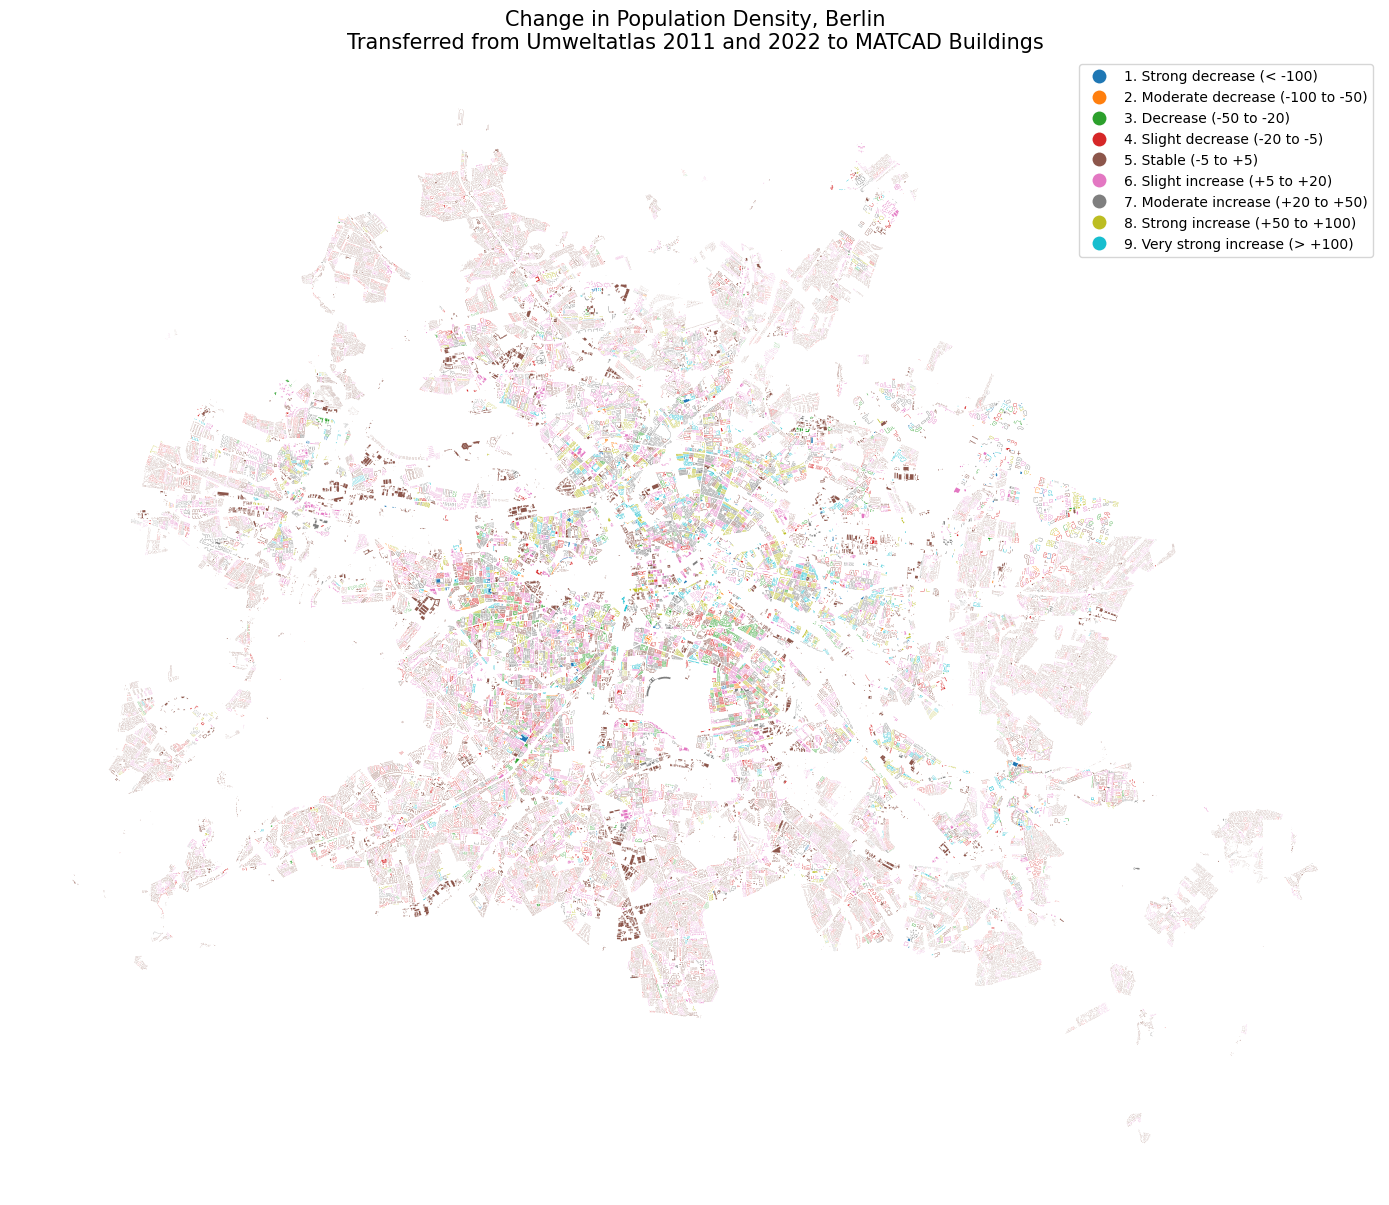

In [65]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 14))

change_df.plot(
    column="density_change_class",
    categorical=True,
    legend=True,
    ax=ax,
    linewidth=0,
    markersize=0.1
)

ax.set_title(
    "Change in Population Density, Berlin\n"
    "Transferred from Umweltatlas 2011 and 2022 to MATCAD Buildings",
    fontsize=15
)

ax.set_axis_off()

plt.tight_layout()
plt.show()

In [66]:
from pathlib import Path

# --------------------------------------------------
# OUTPUT PATHS
# --------------------------------------------------

output_dir = Path(r"C:\Users\deqin\Downloads")

gpkg_output = output_dir / "MATCAD_Energy_Age_Denkmal_PopPressure.gpkg"
csv_output = output_dir / "MATCAD_Energy_Age_Denkmal_PopPressure.csv"

# --------------------------------------------------
# FINAL CLEANUP / DERIVED INDICATOR
# --------------------------------------------------

# Explicit name for the spatial pressure indicator
matcad_final["pop_density_pressure_change"] = (
    matcad_final["density_2022"] - matcad_final["density_2011"]
)

# Optional interpretation as percentage change
matcad_final["pop_density_pressure_pct_change"] = (
    (
        matcad_final["density_2022"] - matcad_final["density_2011"]
    )
    / matcad_final["density_2011"].replace(0, pd.NA)
) * 100

# --------------------------------------------------
# SAVE GEOPACKAGE
# --------------------------------------------------

matcad_final.to_file(
    gpkg_output,
    layer="matcad_population_pressure",
    driver="GPKG"
)

# --------------------------------------------------
# SAVE CSV
# --------------------------------------------------

# CSV cannot store geometry properly, so remove geometry
matcad_csv = matcad_final.drop(columns="geometry").copy()

matcad_csv.to_csv(
    csv_output,
    index=False,
    encoding="utf-8-sig"
)

print("Saved GeoPackage:")
print(gpkg_output)

print("\nSaved CSV:")
print(csv_output)

print("\nFinal dataset shape:", matcad_final.shape)

Saved GeoPackage:
C:\Users\deqin\Downloads\MATCAD_Energy_Age_Denkmal_PopPressure.gpkg

Saved CSV:
C:\Users\deqin\Downloads\MATCAD_Energy_Age_Denkmal_PopPressure.csv

Final dataset shape: (327295, 104)


In [67]:
import pandas as pd
from pathlib import Path

abriss_path = r"C:\Users\deqin\abriss_atlas_outputs\abriss_matcad_clean_post2022_ALL_COLUMNS.csv"

abriss_df = pd.read_csv(abriss_path)

print("Abriss Atlas shape:", abriss_df.shape)
print("\nAbriss Atlas columns:")
print(abriss_df.columns.tolist())

Abriss Atlas shape: (69, 103)

Abriss Atlas columns:
['number', 'title', 'status_raw', 'status', 'address', 'use', 'demolition_year_original', 'description', 'background', 'latitude', 'longitude', 'demolition_year_numeric', 'index_right', 'bldg_gmlid', 'AGS', 'bldg_area', 'bldg_volume', 'bldg_function', 'BtySetID', 'BtyID', 'BtySig', 'Mat_Sum', 'Mat_ConNrm', 'Mat_ConLgt', 'Mat_BriBrt', 'Mat_BriIns', 'Mat_ClyRcv', 'Mat_CalMrt', 'Mat_AnhMrt', 'Mat_LoaMrt', 'Mat_SynMrt', 'Mat_CalScr', 'Mat_AnhScr', 'Mat_AnhDsc', 'Mat_SynScr', 'Mat_SlmBri', 'Mat_AcnBlc', 'Mat_ConBlc', 'Mat_MudBri', 'Mat_GpsPlb', 'Mat_MinCnb', 'Mat_MinIns', 'Mat_ConRcv', 'Mat_FcmRcv', 'Mat_SltRcv', 'Mat_OrgSbs', 'Mat_MinFil', 'Mat_MinGls', 'Mat_NatStn', 'Mat_MinOth', 'Mat_TmbSwn', 'Mat_WodPrc', 'Mat_RnwIns', 'Mat_StrRcv', 'Mat_RnwOth', 'Mat_HcbIns', 'Mat_PlaRcv', 'Mat_HcbRcv', 'Mat_BtmRcv', 'Mat_BtmMem', 'Mat_FemRcv', 'Mat_FemOth', 'Mat_NfeAlm', 'Mat_NfeAlu', 'Mat_NfeCpr', 'Mat_NfeOth', 'id', 'gisid', 'typ_ist', 'typ_mod1',

In [68]:
matcad_columns = set(matcad_final.columns)
abriss_columns = set(abriss_df.columns)

missing_from_matcad = sorted(
    abriss_columns - matcad_columns
)

common_columns = sorted(
    abriss_columns.intersection(matcad_columns)
)

print("Columns in Abriss Atlas but missing from current MATCAD:")
for col in missing_from_matcad:
    print(" -", col)

print("\nNumber of missing columns:", len(missing_from_matcad))

print("\nCommon columns useful for matching:")
for col in common_columns:
    print(" -", col)

Columns in Abriss Atlas but missing from current MATCAD:
 - address
 - background
 - demolition_year_numeric
 - demolition_year_original
 - description
 - index_right
 - latitude
 - longitude
 - match_distance_m
 - number
 - status
 - status_raw
 - title
 - use

Number of missing columns: 14

Common columns useful for matching:
 - AGS
 - BtyID
 - BtySetID
 - BtySig
 - Mat_AcnBlc
 - Mat_AnhDsc
 - Mat_AnhMrt
 - Mat_AnhScr
 - Mat_BriBrt
 - Mat_BriIns
 - Mat_BtmMem
 - Mat_BtmRcv
 - Mat_CalMrt
 - Mat_CalScr
 - Mat_ClyRcv
 - Mat_ConBlc
 - Mat_ConLgt
 - Mat_ConNrm
 - Mat_ConRcv
 - Mat_FcmRcv
 - Mat_FemOth
 - Mat_FemRcv
 - Mat_GpsPlb
 - Mat_HcbIns
 - Mat_HcbRcv
 - Mat_LoaMrt
 - Mat_MinCnb
 - Mat_MinFil
 - Mat_MinGls
 - Mat_MinIns
 - Mat_MinOth
 - Mat_MudBri
 - Mat_NatStn
 - Mat_NfeAlm
 - Mat_NfeAlu
 - Mat_NfeCpr
 - Mat_NfeOth
 - Mat_OrgSbs
 - Mat_PlaRcv
 - Mat_RnwIns
 - Mat_RnwOth
 - Mat_SlmBri
 - Mat_SltRcv
 - Mat_StrRcv
 - Mat_Sum
 - Mat_SynMrt
 - Mat_SynScr
 - Mat_TmbSwn
 - Mat_WodPrc
 - ag

In [69]:
candidate_keys = [
    "gisid",
    "id",
    "age_schluessel",
    "building_idx"
]

for key in candidate_keys:
    print(
        key,
        "| MATCAD:", key in matcad_final.columns,
        "| Abriss:", key in abriss_df.columns
    )

gisid | MATCAD: True | Abriss: True
id | MATCAD: True | Abriss: True
age_schluessel | MATCAD: True | Abriss: True
building_idx | MATCAD: True | Abriss: False


In [70]:
candidate_keys = [
    "gisid",
    "id",
    "age_schluessel",
    "building_idx"
]

for key in candidate_keys:
    print(
        key,
        "| MATCAD:", key in matcad_final.columns,
        "| Abriss:", key in abriss_df.columns
    )

gisid | MATCAD: True | Abriss: True
id | MATCAD: True | Abriss: True
age_schluessel | MATCAD: True | Abriss: True
building_idx | MATCAD: True | Abriss: False


In [71]:
# Use the stable building identifier
merge_key = "gisid"

# Only add columns that are absent from matcad_final
abriss_columns_to_add = [
    col for col in missing_from_matcad
    if col != merge_key
]

# Include the merge key
abriss_subset = abriss_df[
    [merge_key] + abriss_columns_to_add
].copy()

# Check whether the Abriss dataset has duplicate building IDs
print(
    "Duplicate Abriss GISIDs:",
    abriss_subset[merge_key].duplicated().sum()
)

Duplicate Abriss GISIDs: 1


In [72]:
duplicate_gisids = abriss_df[
    abriss_df["gisid"].duplicated(keep=False)
].sort_values("gisid")

duplicate_gisids

,number,title,status_raw,status,address,use,demolition_year_original,description,background,latitude,...,x1971_1980,x1981_1990,x1991_2000,x2001_2010,x2011_2015,ueberw_dekade_woh_neu,ew2015,typ,typklar,match_distance_m
38,609,"Hotel Sylter Hof, Berlin",bedroht,bedroht,"Kurfürstenstraße 114-116, 10787 Berlin",gewerbe,2024,Zeittypisches Hotel-Hochhaus,Das Hotel Sylter Hof wurde im Herbst 2022 gesc...,52.503358,...,NaN,NaN,NaN,NaN,NaN,gemischte Baualtersklasse,367.0,8.0,"Heterogene, innerstädtische Mischbebauung, Lüc...",0.0
64,1592,"Hotel Sylter Hof, Berlin",bedroht,bedroht,"Kurfürstenstraße 114-116, 10787 Berlin",andereNutzung,2024,"Der 6-geschossige, quaderförmig längsgezogene ...",Das Hotel wurde 2000 gesamt und 2012 teilrenov...,52.503386,...,NaN,NaN,NaN,NaN,NaN,gemischte Baualtersklasse,367.0,8.0,"Heterogene, innerstädtische Mischbebauung, Lüc...",0.0


In [73]:
# Use the stable building identifier
merge_key = "gisid"

# Only add columns that are missing from matcad_final
abriss_columns_to_add = [
    col for col in missing_from_matcad
    if col != merge_key
]

abriss_subset = abriss_df[
    [merge_key] + abriss_columns_to_add
].copy()

# Merge while allowing duplicate Abriss records
matcad_final = matcad_final.merge(
    abriss_subset,
    on=merge_key,
    how="left",
    validate="many_to_many"
)

print("Updated shape:", matcad_final.shape)
print("Original MATCAD building count:", matcad["gisid"].nunique())
print("Updated unique GISID count:", matcad_final["gisid"].nunique())

Updated shape: (327296, 118)
Original MATCAD building count: 327215
Updated unique GISID count: 327215


In [74]:
abriss_related_columns = [
    col for col in matcad_final.columns
    if any(term in col.lower() for term in [
        "abriss",
        "demol",
        "abbruch",
        "status",
        "address",
        "original",
        "description",
        "background"
    ])
]

print(abriss_related_columns)

['denkmal_status', 'address', 'background', 'demolition_year_numeric', 'demolition_year_original', 'description', 'status', 'status_raw']


In [75]:
inspection_columns = [
    "gisid",
    "bldg_area",
    "BtySig",
    "density_2011",
    "density_2022",
    "pop_density_pressure_change",
    "address",
    "status",
    "status_raw",
    "demolition_year_numeric",
    "demolition_year_original",
    "denkmal_status"
]

# Show only columns that actually exist
inspection_columns = [
    col for col in inspection_columns
    if col in matcad_final.columns
]

matcad_final[inspection_columns].head(10)

,gisid,bldg_area,BtySig,density_2011,density_2022,pop_density_pressure_change,address,status,status_raw,demolition_year_numeric,demolition_year_original,denkmal_status
0,G427469,10434.53,TRD,1.0,0.00,-1.00,NaN,NaN,NaN,NaN,NaN,False
1,G406691,836.77,MFH,76.0,67.48,-8.52,NaN,NaN,NaN,NaN,NaN,False
2,G172069,7.38,NAS,34.0,35.79,1.79,NaN,NaN,NaN,NaN,NaN,True
3,G409705,8.19,NAS,31.0,29.82,-1.18,NaN,NaN,NaN,NaN,NaN,False
4,G361278,6.19,NAS,30.0,34.03,4.03,NaN,NaN,NaN,NaN,NaN,False
5,G172645,22.74,NAS,6.0,12.53,6.53,NaN,NaN,NaN,NaN,NaN,False
6,G177898,57.76,NAS,31.0,36.90,5.90,NaN,NaN,NaN,NaN,NaN,False
7,G202339,6.53,NAS,28.0,23.37,-4.63,NaN,NaN,NaN,NaN,NaN,False
8,G152015,8.91,NAS,30.0,33.20,3.20,NaN,NaN,NaN,NaN,NaN,False
9,G175914,17.47,NAS,NaN,0.00,NaN,NaN,NaN,NaN,NaN,NaN,False


In [76]:
print("Status value counts:")
print(matcad_final["status"].value_counts(dropna=False))

print("\nStatus_raw value counts:")
print(matcad_final["status_raw"].value_counts(dropna=False))

Status value counts:
status
NaN                327227
abgerissen             34
abrissbestatigt        22
bedroht                13
Name: count, dtype: int64

Status_raw value counts:
status_raw
NaN                327227
abgerissen             33
abrissBestatigt        22
bedroht                13
Abgerissen              1
Name: count, dtype: int64


In [77]:
matcad_final["reporting_of_demolition"] = (
    matcad_final["address"]
    .notna()
    .map({
        True: "reported",
        False: "not_reported"
    })
)

matcad_final["reporting_of_demolition"].value_counts(dropna=False)

reporting_of_demolition
not_reported    327227
reported            69
Name: count, dtype: int64

In [78]:
final_check_columns = [
    "gisid",
    "density_2011",
    "density_2022",
    "pop_density_pressure_change",
    "reporting_of_demolition",
    "status",
    "address",
    "demolition_year_numeric"
]

final_check_columns = [
    col for col in final_check_columns
    if col in matcad_final.columns
]

matcad_final[final_check_columns].head(10)

,gisid,density_2011,density_2022,pop_density_pressure_change,reporting_of_demolition,status,address,demolition_year_numeric
0,G427469,1.0,0.00,-1.00,not_reported,NaN,NaN,NaN
1,G406691,76.0,67.48,-8.52,not_reported,NaN,NaN,NaN
2,G172069,34.0,35.79,1.79,not_reported,NaN,NaN,NaN
3,G409705,31.0,29.82,-1.18,not_reported,NaN,NaN,NaN
4,G361278,30.0,34.03,4.03,not_reported,NaN,NaN,NaN
5,G172645,6.0,12.53,6.53,not_reported,NaN,NaN,NaN
6,G177898,31.0,36.90,5.90,not_reported,NaN,NaN,NaN
7,G202339,28.0,23.37,-4.63,not_reported,NaN,NaN,NaN
8,G152015,30.0,33.20,3.20,not_reported,NaN,NaN,NaN
9,G175914,NaN,0.00,NaN,not_reported,NaN,NaN,NaN


In [79]:
# Display the complete head with all columns visible

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.width", 250)

matcad_final.head()

,bldg_gmlid,AGS,bldg_area,bldg_volume,bldg_function,BtySetID,BtyID,BtySig,Mat_Sum,Mat_ConNrm,Mat_ConLgt,Mat_BriBrt,Mat_BriIns,Mat_ClyRcv,Mat_CalMrt,Mat_AnhMrt,Mat_LoaMrt,Mat_SynMrt,Mat_CalScr,Mat_AnhScr,Mat_AnhDsc,Mat_SynScr,Mat_SlmBri,Mat_AcnBlc,Mat_ConBlc,Mat_MudBri,Mat_GpsPlb,Mat_MinCnb,Mat_MinIns,Mat_ConRcv,Mat_FcmRcv,Mat_SltRcv,Mat_OrgSbs,Mat_MinFil,Mat_MinGls,Mat_NatStn,Mat_MinOth,Mat_TmbSwn,Mat_WodPrc,Mat_RnwIns,Mat_StrRcv,Mat_RnwOth,Mat_HcbIns,Mat_PlaRcv,Mat_HcbRcv,Mat_BtmRcv,Mat_BtmMem,Mat_FemRcv,Mat_FemOth,Mat_NfeAlm,Mat_NfeAlu,Mat_NfeCpr,Mat_NfeOth,id,gisid,typ_ist,typ_mod1,k2_w_l,nwbz,overlap_ratio_matcad,bbox_length_m,bbox_width_m,footprint_area_m2,height_proxy_m,energy_intensity_kwh_m3a,denkmal_status,index_age,age_schluessel,freistehen,anderertyp,doppelhaus,gereihtes,x_bis_1900,x1901_1910,x1911_1920,x1921_1930,x1931_1940,x1941_1950,x1951_1960,x1961_1970,x1971_1980,x1981_1990,x1991_2000,x2001_2010,x2011_2015,ueberw_dekade_woh_neu,ew2015,typ,typklar,geometry,building_idx,schluessel_2011,pop_2011,area_ha_2011,density_2011,overlap_area_m2_2011,schluessel_2022,pop_2022,area_m2_2022,density_2022,overlap_area_m2_2022,density_change,pop_density_pressure_change,pop_density_pressure_pct_change,address,background,demolition_year_numeric,demolition_year_original,description,index_right,latitude,longitude,match_distance_m,number,status,status_raw,title,use,reporting_of_demolition
0,DEBE10YYW00002xf,11000000,10434.53,78359.13,31001_2054,4.0,157,TRD,35189.650,17903.029,33.915,1562.810,0.0,82.481,672.694,91.744,0.0,0.0,2603.590,77.722,0.0,54.882,342.715,252.805,0.000,0.0,74.989,21.566,133.171,117.085,0.0,0.504,0.0,8937.334,21.367,45.411,1.544,232.812,16.114,0.407,0.069,0.191,53.694,2.949,11.743,4.759,0.0,0.208,1782.037,0.0,53.309,0.0,0.0,a_waermeversorg_gebaeudedaten_2022.G427469,G427469,Nichtwohngebäude,Nichtwohngebäude,K01 - beheizt,1438202.0,1.0,122.847,135.610,10434.386454,7.509702,18.353981,False,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,NaN,None,"MULTIPOLYGON (((406337.591 5818294.2, 406336.521 5818290.364, 406332.449 581...",0,2301910241000100,3.0,5.66,1.0,10434.386454,2301910241000100,0.0,56684.69,0.00,10434.386454,-1.00,-1.00,-100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,not_reported
1,DEBE09YYP0003eLR,11000000,836.77,13304.39,31001_1010,4.0,246,MFH,6182.778,2697.168,63.740,1072.658,0.0,19.552,510.692,172.422,0.0,0.0,242.900,70.861,0.0,0.000,443.765,31.721,0.000,0.0,5.996,7.772,31.809,0.000,0.0,0.948,0.0,336.294,8.432,85.344,2.902,51.652,1.085,0.765,0.130,0.358,2.586,0.000,5.602,7.742,0.0,0.390,307.492,0.0,0.000,0.0,0.0,a_waermeversorg_gebaeudedaten_2022.G406691,G406691,Wohngebäude - zentrale Versorgung,Wohngebäude - zentrale Versorgung,"K10 - Wohngebäude inkl. Mischnutzungen (nachrichtlich, ohne Beurteilung)",231117.0,1.0,77.907,11.688,836.761827,15.899853,17.371484,False,8458.0,1601436081000300,5.0,1.0,5.0,10.0,NaN,NaN,NaN,4.0,5.0,NaN,7.0,5.0,NaN,NaN,NaN,NaN,None,1951-1960,139.0,11.0,"Freie Zeilenbebauung (1950er-1970er), mit landschaftlichem Siedlungsgrün, 3–...","MULTIPOLYGON (((404949.662 5812378.001, 404949.662 5812376.346, 404942.396 5...",1,1601436081000300,143.0,1.89,76.0,836.761827,1601436081000300,133.0,19710.98,67.48,836.761827,-8.52,-8.52,-11.210526,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,not_reported
2,DEBE05YYR0000Iro,11000000,7.38,17.86,31001_1000,4.0,159,NAS,14.562,9.922,0.000,0.036,0.0,0.000,0.054,0.000,0.0,0.0,0.897,0.000,0.0,0.326,0.196,0.000,0.050,0.0,0.000,0.000,0.000,0.000,0.0,0.000,0.0,2.065,0.001,0.034,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.001,0.002,0.018,0.0,0.000,0.959,0.0,0.001,0.0,0.0,a_waermeversorg_gebaeudedaten_2022.G172069,G172069,Wohngebäude - dezentrale Versorgung,Wohngebäude - dezentrale Versorgung,"K10 - Wohngebäude inkl. Mischnutzungen (nachrichtlich, ohne Beurteilung)",547.0,1.0,4.295,3.706,7.380064,2.420033,30.627100,True,2736.0,0800390201000000,NaN,NaN,22.0,NaN,NaN,NaN,NaN,NaN,22.0,NaN,NaN,NaN,Na

In [80]:
# Display the complete head with all columns visible

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.width", 250)

matcad_final.head()

,bldg_gmlid,AGS,bldg_area,bldg_volume,bldg_function,BtySetID,BtyID,BtySig,Mat_Sum,Mat_ConNrm,Mat_ConLgt,Mat_BriBrt,Mat_BriIns,Mat_ClyRcv,Mat_CalMrt,Mat_AnhMrt,Mat_LoaMrt,Mat_SynMrt,Mat_CalScr,Mat_AnhScr,Mat_AnhDsc,Mat_SynScr,Mat_SlmBri,Mat_AcnBlc,Mat_ConBlc,Mat_MudBri,Mat_GpsPlb,Mat_MinCnb,Mat_MinIns,Mat_ConRcv,Mat_FcmRcv,Mat_SltRcv,Mat_OrgSbs,Mat_MinFil,Mat_MinGls,Mat_NatStn,Mat_MinOth,Mat_TmbSwn,Mat_WodPrc,Mat_RnwIns,Mat_StrRcv,Mat_RnwOth,Mat_HcbIns,Mat_PlaRcv,Mat_HcbRcv,Mat_BtmRcv,Mat_BtmMem,Mat_FemRcv,Mat_FemOth,Mat_NfeAlm,Mat_NfeAlu,Mat_NfeCpr,Mat_NfeOth,id,gisid,typ_ist,typ_mod1,k2_w_l,nwbz,overlap_ratio_matcad,bbox_length_m,bbox_width_m,footprint_area_m2,height_proxy_m,energy_intensity_kwh_m3a,denkmal_status,index_age,age_schluessel,freistehen,anderertyp,doppelhaus,gereihtes,x_bis_1900,x1901_1910,x1911_1920,x1921_1930,x1931_1940,x1941_1950,x1951_1960,x1961_1970,x1971_1980,x1981_1990,x1991_2000,x2001_2010,x2011_2015,ueberw_dekade_woh_neu,ew2015,typ,typklar,geometry,building_idx,schluessel_2011,pop_2011,area_ha_2011,density_2011,overlap_area_m2_2011,schluessel_2022,pop_2022,area_m2_2022,density_2022,overlap_area_m2_2022,density_change,pop_density_pressure_change,pop_density_pressure_pct_change,address,background,demolition_year_numeric,demolition_year_original,description,index_right,latitude,longitude,match_distance_m,number,status,status_raw,title,use,reporting_of_demolition
0,DEBE10YYW00002xf,11000000,10434.53,78359.13,31001_2054,4.0,157,TRD,35189.650,17903.029,33.915,1562.810,0.0,82.481,672.694,91.744,0.0,0.0,2603.590,77.722,0.0,54.882,342.715,252.805,0.000,0.0,74.989,21.566,133.171,117.085,0.0,0.504,0.0,8937.334,21.367,45.411,1.544,232.812,16.114,0.407,0.069,0.191,53.694,2.949,11.743,4.759,0.0,0.208,1782.037,0.0,53.309,0.0,0.0,a_waermeversorg_gebaeudedaten_2022.G427469,G427469,Nichtwohngebäude,Nichtwohngebäude,K01 - beheizt,1438202.0,1.0,122.847,135.610,10434.386454,7.509702,18.353981,False,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,NaN,None,"MULTIPOLYGON (((406337.591 5818294.2, 406336.521 5818290.364, 406332.449 581...",0,2301910241000100,3.0,5.66,1.0,10434.386454,2301910241000100,0.0,56684.69,0.00,10434.386454,-1.00,-1.00,-100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,not_reported
1,DEBE09YYP0003eLR,11000000,836.77,13304.39,31001_1010,4.0,246,MFH,6182.778,2697.168,63.740,1072.658,0.0,19.552,510.692,172.422,0.0,0.0,242.900,70.861,0.0,0.000,443.765,31.721,0.000,0.0,5.996,7.772,31.809,0.000,0.0,0.948,0.0,336.294,8.432,85.344,2.902,51.652,1.085,0.765,0.130,0.358,2.586,0.000,5.602,7.742,0.0,0.390,307.492,0.0,0.000,0.0,0.0,a_waermeversorg_gebaeudedaten_2022.G406691,G406691,Wohngebäude - zentrale Versorgung,Wohngebäude - zentrale Versorgung,"K10 - Wohngebäude inkl. Mischnutzungen (nachrichtlich, ohne Beurteilung)",231117.0,1.0,77.907,11.688,836.761827,15.899853,17.371484,False,8458.0,1601436081000300,5.0,1.0,5.0,10.0,NaN,NaN,NaN,4.0,5.0,NaN,7.0,5.0,NaN,NaN,NaN,NaN,None,1951-1960,139.0,11.0,"Freie Zeilenbebauung (1950er-1970er), mit landschaftlichem Siedlungsgrün, 3–...","MULTIPOLYGON (((404949.662 5812378.001, 404949.662 5812376.346, 404942.396 5...",1,1601436081000300,143.0,1.89,76.0,836.761827,1601436081000300,133.0,19710.98,67.48,836.761827,-8.52,-8.52,-11.210526,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,not_reported
2,DEBE05YYR0000Iro,11000000,7.38,17.86,31001_1000,4.0,159,NAS,14.562,9.922,0.000,0.036,0.0,0.000,0.054,0.000,0.0,0.0,0.897,0.000,0.0,0.326,0.196,0.000,0.050,0.0,0.000,0.000,0.000,0.000,0.0,0.000,0.0,2.065,0.001,0.034,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.001,0.002,0.018,0.0,0.000,0.959,0.0,0.001,0.0,0.0,a_waermeversorg_gebaeudedaten_2022.G172069,G172069,Wohngebäude - dezentrale Versorgung,Wohngebäude - dezentrale Versorgung,"K10 - Wohngebäude inkl. Mischnutzungen (nachrichtlich, ohne Beurteilung)",547.0,1.0,4.295,3.706,7.380064,2.420033,30.627100,True,2736.0,0800390201000000,NaN,NaN,22.0,NaN,NaN,NaN,NaN,NaN,22.0,NaN,NaN,NaN,Na

In [81]:
from pathlib import Path

output_dir = Path(r"C:\Users\deqin\Downloads")

final_gpkg = output_dir / "MATCAD_Energy_Age_Denkmal_PopPressure_Abriss.gpkg"
final_csv = output_dir / "MATCAD_Energy_Age_Denkmal_PopPressure_Abriss.csv"

# Save GeoPackage with geometry
matcad_final.to_file(
    final_gpkg,
    layer="matcad_population_pressure_abriss",
    driver="GPKG"
)

# Save CSV without geometry
matcad_final.drop(columns="geometry").to_csv(
    final_csv,
    index=False,
    encoding="utf-8-sig"
)

print("GeoPackage saved:")
print(final_gpkg)

print("\nCSV saved:")
print(final_csv)

print("\nFinal dataset shape:", matcad_final.shape)

GeoPackage saved:
C:\Users\deqin\Downloads\MATCAD_Energy_Age_Denkmal_PopPressure_Abriss.gpkg

CSV saved:
C:\Users\deqin\Downloads\MATCAD_Energy_Age_Denkmal_PopPressure_Abriss.csv

Final dataset shape: (327296, 119)
